In [2]:
#Imports
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

In [ ]:
#Loading data. (renamed csv files for simplicity)
#May need to edit path to where datais stored on your computer.
sql_df = 'modified.csv'

#------------------------------------------------------------
#For model evaluation
df = pd.read_csv(sql_df)
#Extras
original_df = train_df.copy()
analysis_df = df.copy()

In [ ]:
#Lists fields and data types
df.dtypes

CustomerID               float64
Age                      float64
Gender                    object
Tenure                   float64
Usage Frequency          float64
Support Calls            float64
Payment Delay            float64
Subscription Type         object
Contract Length           object
Total Spend              float64
Last Interaction         float64
Churn                    float64
Subscription Category     object
Provider Name             object
date                      object
dtype: object

In [ ]:
#drops irrelevant columns for account fields
df = df.drop(columns=[
    "Age",
    "Gender",
    "Tenure",
    "Usage Frequency",
    "Support Calls",
    "Payment Delay",
    "Subscription Type",
    "Contract Length",
    "Last Interaction",
    "Churn"
], errors="ignore")

In [ ]:
#results now match fields on frontend
df.dtypes

CustomerID               float64
Total Spend              float64
Subscription Category     object
Provider Name             object
date                      object
dtype: object

In [ ]:
#Renaming fields to completely match frontend
df = df[[
    "CustomerID",
    "Total Spend",
    "Subscription Category",
    "Provider Name",
    "date"
]].rename(columns={
    "CustomerID": "id",
    "Total Spend": "cost",
    "Subscription Category": "category",
    "Provider Name": "store_name",
    "date": "date"
}, errors="ignore")

In [ ]:
#Confirmation of renamed fields
df.dtypes

id            float64
cost          float64
category       object
store_name     object
date           object
dtype: object

In [ ]:
#Generating csv file to represent modifications
df.to_csv("cleaned_data.csv", index=False)

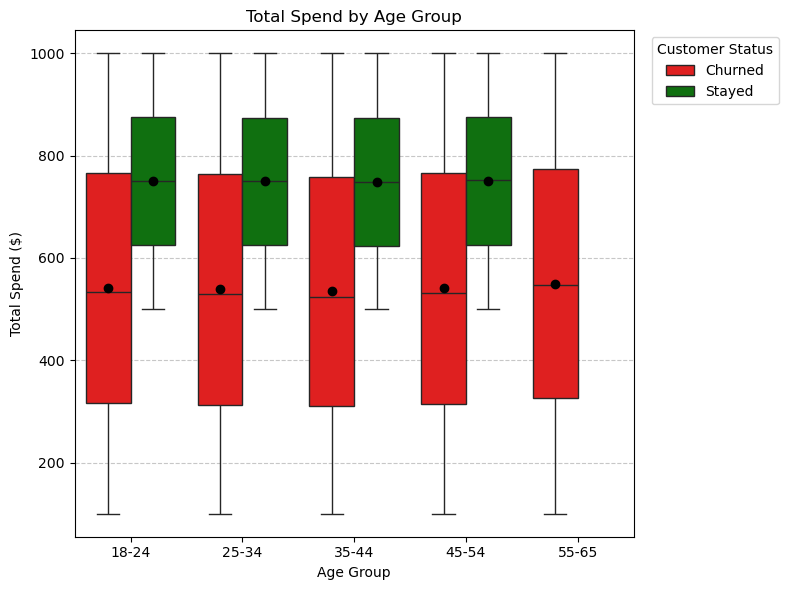

In [ ]:
#Showcases total spent by age group.
original_df['Churn Label'] = original_df['Churn'].map({
    0: 'Stayed',
    1: 'Churned'
})
original_df['Age Group'].value_counts(dropna=False)

age_bins = [18, 25, 35, 45, 55, 66]
age_labels = ['18-24', '25-34', '35-44', '45-54', '55-65']

original_df['Age Group'] = pd.cut(
    original_df['Age'],
    bins=age_bins,
    labels=age_labels,
    right=False
)

churn_colors = {
    'Stayed': 'green',
    'Churned': 'red'
}

plt.figure(figsize=(8,6))

sns.boxplot(
    data=original_df,
    x='Age Group',
    y='Total Spend',
    hue='Churn Label',
    palette=churn_colors,
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "black",
        "markeredgecolor": "black"
    }
)

plt.title('Total Spend by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Spend ($)')

plt.legend(
    title='Customer Status',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
#Easier to see mean averages.
original_df.groupby('Age Group')['Total Spend'].mean()

C:\Users\firea\AppData\Local\Temp\ipykernel_10436\1104772877.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  original_df.groupby('Age Group')['Total Spend'].mean()


Age Group
18-24    631.871562
25-34    644.296677
35-44    656.530745
45-54    638.815679
55-65    549.215247
Name: Total Spend, dtype: float64

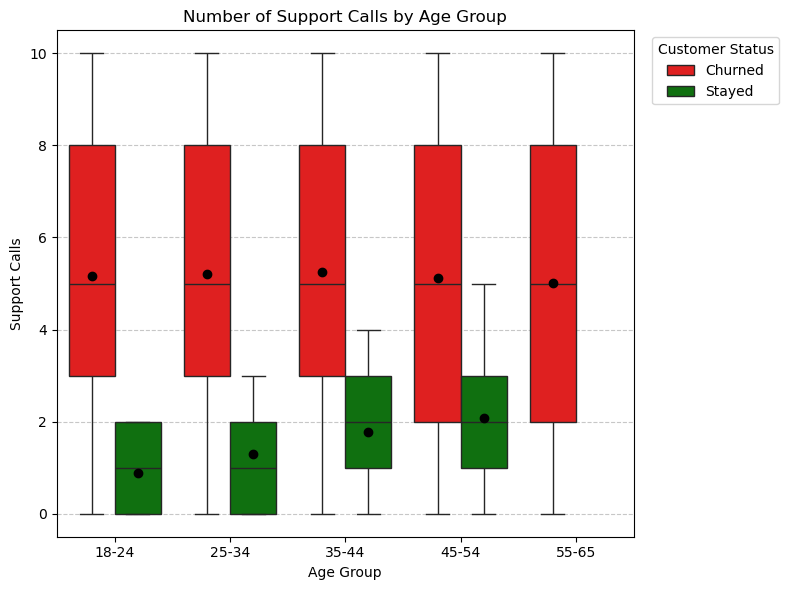

In [ ]:
original_df['Churn Label'] = original_df['Churn'].map({
    0: 'Stayed',
    1: 'Churned'
})
original_df['Age Group'].value_counts(dropna=False)

age_bins = [18, 25, 35, 45, 55, 66]
age_labels = ['18-24', '25-34', '35-44', '45-54', '55-65']

original_df['Age Group'] = pd.cut(
    original_df['Age'],
    bins=age_bins,
    labels=age_labels,
    right=False
)

churn_colors = {
    'Stayed': 'green',
    'Churned': 'red'
}

plt.figure(figsize=(8,6))

sns.boxplot(
    data=original_df,
    x='Age Group',
    y='Support Calls',
    hue='Churn Label',
    palette=churn_colors,
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "black",
        "markeredgecolor": "black"
    }
)

plt.title('Number of Support Calls by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Support Calls')

plt.legend(
    title='Customer Status',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# ---------------- User input for subscription churn predictions

In [2]:
print("Please enter your details to predict churn probability.")
original_df = original_df.drop(columns=['CustomerID'], errors='ignore')

Please enter your details to predict churn probability.
